In [85]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/new_york_listings_2024.csv')

# Show the first 5 rows to confirm it loaded correctly
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,1312228,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.683710,-73.964610,Private room,55.0,...,2015-12-20,0.03,1,0,0,No License,5.0,1,1,Not specified
1,45277537,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,...,2023-05-01,0.24,139,364,2,No License,4.67,2,1,1
2,971353993633883038,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,...,2023-12-18,1.67,1,343,6,Exempt,4.17,1,2,1
3,3857863,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,2023-09-17,1.38,2,363,12,No License,4.64,1,1,1
4,40896611,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85.0,...,2023-12-03,0.24,133,335,3,No License,4.91,Studio,1,1


In [86]:
df.info()
#check what kind of data types we're dealing with

print(df.duplicated().sum())
#this shows if there are any duplicate rows, since False is 0. if it's 0 then there are no duplicate rows

print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   name                            20758 non-null  str    
 2   host_id                         20758 non-null  int64  
 3   host_name                       20758 non-null  str    
 4   neighbourhood_group             20758 non-null  str    
 5   neighbourhood                   20758 non-null  str    
 6   latitude                        20758 non-null  float64
 7   longitude                       20758 non-null  float64
 8   room_type                       20758 non-null  str    
 9   price                           20758 non-null  float64
 10  minimum_nights                  20758 non-null  int64  
 11  number_of_reviews               20758 non-null  int64  
 12  last_review                     20758 non-n

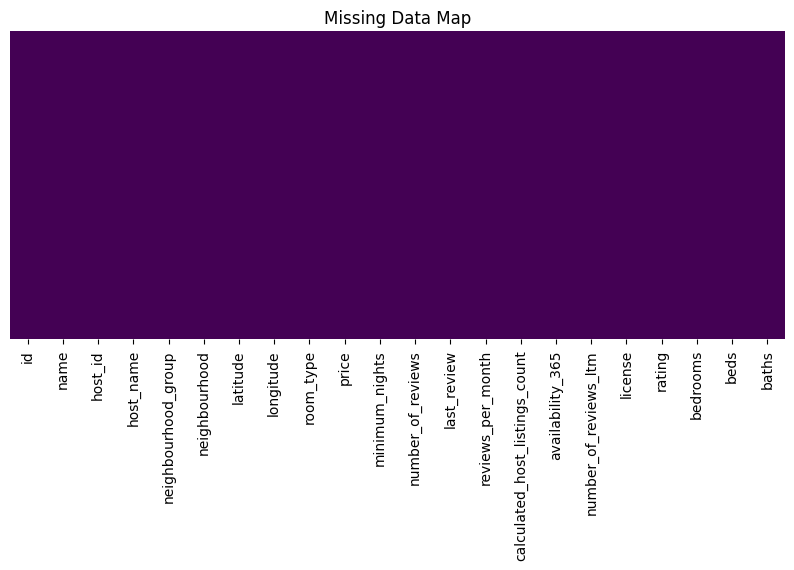

In [87]:
import seaborn as sns
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Data Map")
plt.show()

neighbourhood_group
Manhattan        8038
Brooklyn         7719
Queens           3761
Bronx             949
Staten Island     291
Name: count, dtype: int64


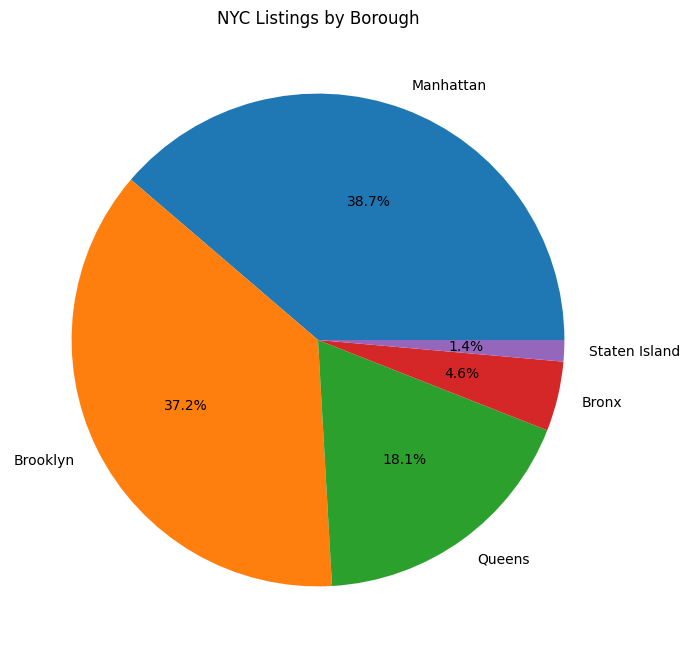

In [88]:
from pandas.plotting import autocorrelation_plot
#a look at the boroughs
borough_counts = df['neighbourhood_group'].value_counts()
print(borough_counts)


#pie chart to show market share
borough_counts.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8), title='NYC Listings by Borough')
plt.ylabel('')
plt.show()

count     20758.000000
mean        187.776616
std        1022.797208
min          10.000000
25%          80.000000
50%         125.000000
75%         199.000000
max      100000.000000
Name: price, dtype: float64


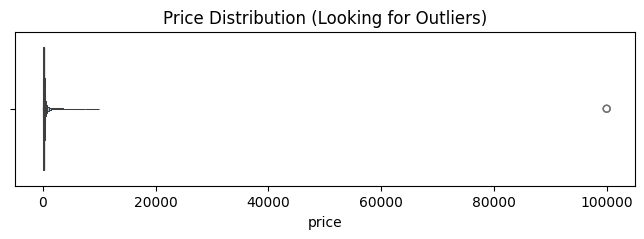

In [89]:
#for the sake of simplicity, we get rid of outliers. further analysis should be more careful in checking outliers. First we show the outliers in a box plot
print(df['price'].describe())

plt.figure(figsize=(8, 2))
sns.boxenplot(x=df['price'])
plt.title("Price Distribution (Looking for Outliers)")
plt.show()

In [90]:
#as a first step to check the typical listing, we will get rid of the outliers

df_clean = df[(df['price'] > 0) & (df['price'] < 1000)].copy()

rows_removed = len(df) - len(df_clean)
print(f"Removed {rows_removed} listings (Price $0 or > $1000)")

print(df_clean['price'].describe())

Removed 198 listings (Price $0 or > $1000)
count    20560.000000
mean       160.034339
std        128.101041
min         10.000000
25%         80.000000
50%        125.000000
75%        198.000000
max        999.000000
Name: price, dtype: float64


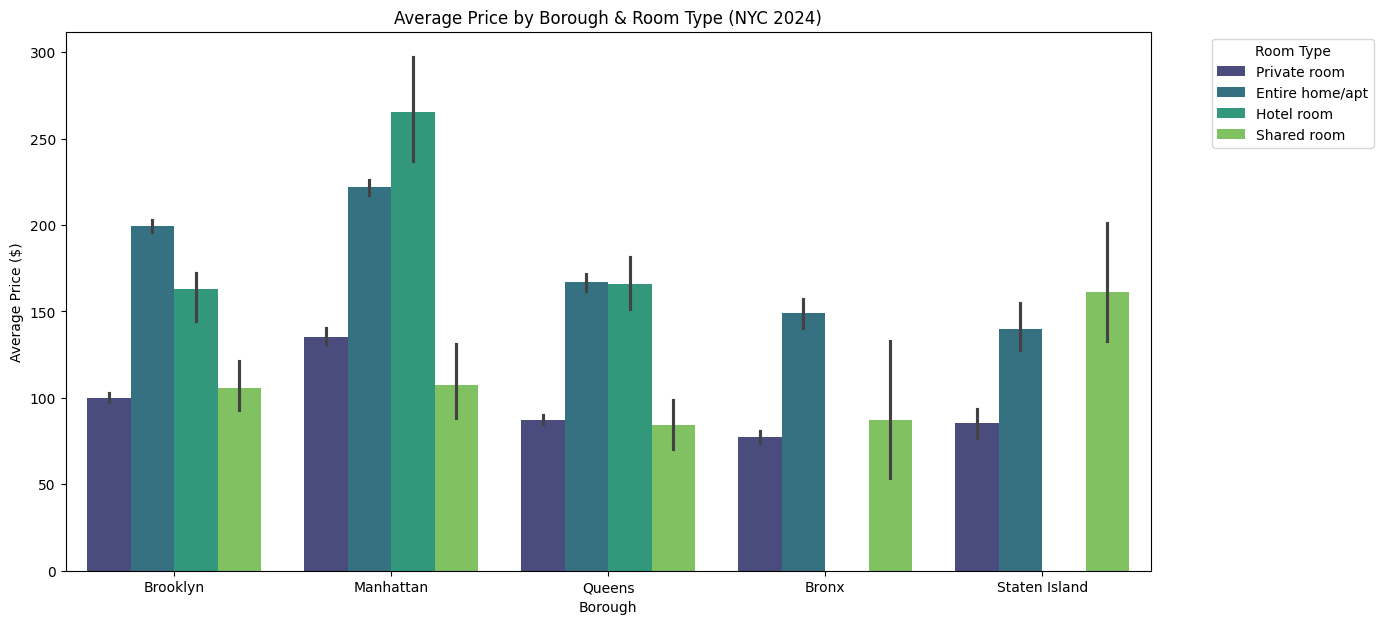

In [91]:
plt.figure(figsize=(14, 7))

# We add 'hue' to split each borough bar into Room Types
sns.barplot(
    data=df_clean, 
    x='neighbourhood_group', 
    y='price', 
    hue='room_type', 
    palette='viridis'
)

plt.title("Average Price by Borough & Room Type (NYC 2024)")
plt.ylabel("Average Price ($)")
plt.xlabel("Borough")
plt.legend(title="Room Type", bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside the plot
plt.show()

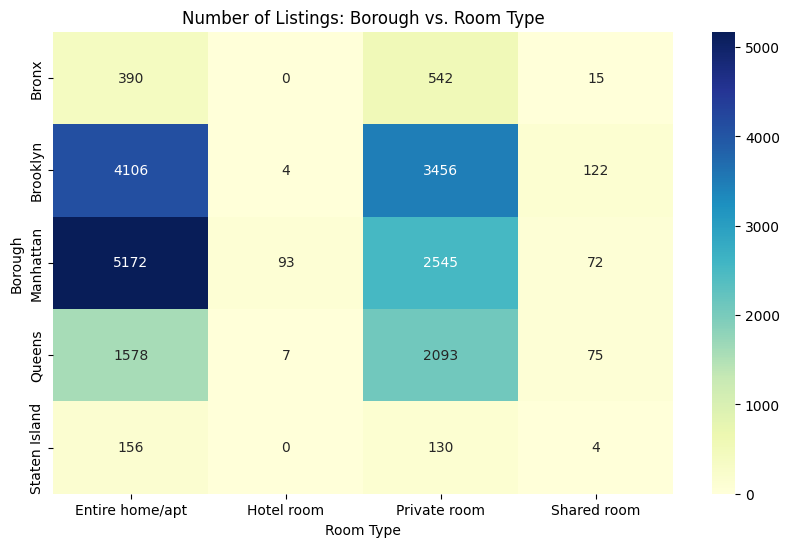

In [92]:
#as we see Manhattan's prices are the highest, we would try to explore the prices there and how they're related to room types

price_matrix = pd.crosstab(df_clean['neighbourhood_group'], df_clean['room_type'])

plt.figure(figsize=(10, 6))
sns.heatmap(price_matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Number of Listings: Borough vs. Room Type")
plt.xlabel("Room Type")
plt.ylabel("Borough")
plt.show()